# Part 2: Classical Classification on CIFAR-10

## Overview
In this notebook, we analyze the CIFAR-10 dataset using three classical machine learning models: Logistic Regression, Linear SVM, and KNN. The dataset contains 60,000 color images (32×32 pixels) across 10 classes.

**Dataset source:** https://www.cs.toronto.edu/~kriz/cifar.html  
**Target:** Classify images into 10 categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12
MAIN_COLOR = '#2c7bb6'
SECOND_COLOR = '#d7191c'

In [35]:
# Reproducibility
SEED = 42

import random
random.seed(SEED)

np.random.seed(SEED)


In [36]:
import pickle
import os
import tarfile
import urllib.request

# Download + extract CIFAR-10 (python version) without shell commands
URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
TAR_NAME = "cifar-10-python.tar.gz"
EXTRACTED_DIR = "cifar-10-batches-py"

if not os.path.isdir(EXTRACTED_DIR):
    if not os.path.isfile(TAR_NAME):
        print("Downloading CIFAR-10...")
        urllib.request.urlretrieve(URL, TAR_NAME)
        print("Download complete.")
    print("Extracting CIFAR-10...")
    with tarfile.open(TAR_NAME, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete.")
else:
    print("CIFAR-10 already extracted.")

def load_cifar10_batch(filename):
    with open(filename, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    X = batch[b'data']
    y = batch[b'labels']
    return X, y

# Load all training batches
X_train_all = []
y_train_all = []
for i in range(1, 6):
    X, y = load_cifar10_batch(os.path.join(EXTRACTED_DIR, f"data_batch_{i}"))
    X_train_all.append(X)
    y_train_all.extend(y)

X_train_full = np.concatenate(X_train_all)
y_train_full = np.array(y_train_all)

# Load test set
X_test_full, y_test_full = load_cifar10_batch(os.path.join(EXTRACTED_DIR, "test_batch"))
y_test_full = np.array(y_test_full)

print("Train size:", X_train_full.shape)
print("Test size:", X_test_full.shape)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


Download complete.
Extracting CIFAR-10...
Extraction complete.
Train size: (50000, 3072)
Test size: (10000, 3072)


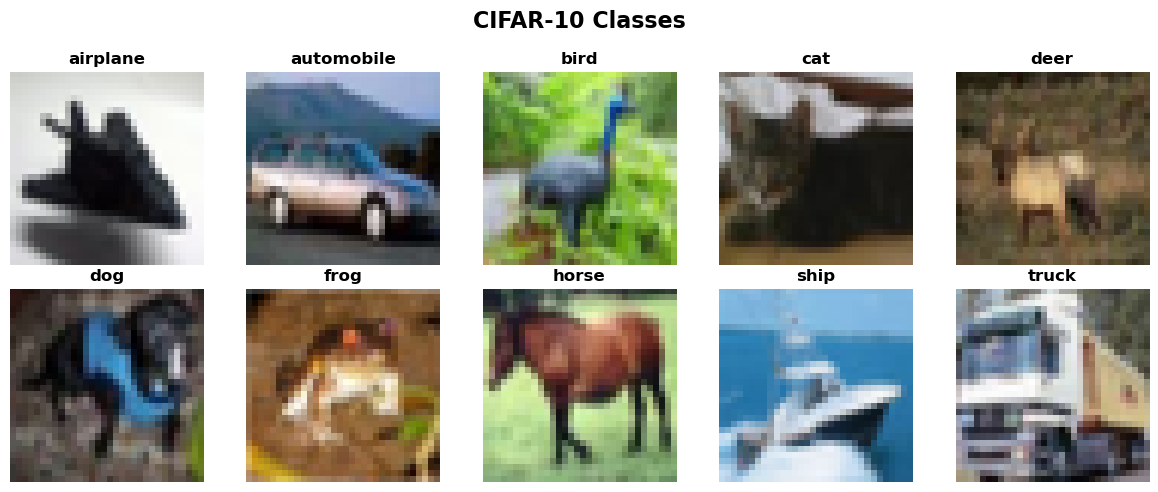

In [37]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    # Get first image of each class
    idx = np.where(y_train_full == i)[0][0]
    img = X_train_full[idx].reshape(3, 32, 32).transpose(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(class_names[i], fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('CIFAR-10 Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

# Use subset for speed (5000 train, 1000 val, full test)
X_train_sub = X_train_full[:5000]
y_train_sub = y_train_full[:5000]

# Normalize pixel values to [0, 1]
X_train_sub = X_train_sub / 255.0
X_test = X_test_full / 255.0

# Split train into train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_sub, y_train_sub, test_size=0.2, random_state=SEED)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])
# Use the SAME training subset for all classical models (fair + faster)
MODEL_TRAIN_N = 1000
rng = np.random.default_rng(SEED)
model_idx = rng.choice(X_train_scaled.shape[0], size=MODEL_TRAIN_N, replace=False)

X_train_model = X_train_scaled[model_idx]
y_train_model = y_train[model_idx]

print("Model-train subset size (shared by LR/SVM/KNN):", X_train_model.shape[0])


Train size: 4000
Validation size: 1000
Test size: 10000
Model-train subset size (shared by LR/SVM/KNN): 1000


## 2.2 Logistic Regression
We evaluate regularization strength C over values [0.001, 0.01, 0.1, 1, 10] and select the best value based on validation accuracy.

C=0.001 | Val Accuracy: 0.366
C=0.010 | Val Accuracy: 0.294
C=0.100 | Val Accuracy: 0.266
C=1.000 | Val Accuracy: 0.249
C=10.000 | Val Accuracy: 0.247


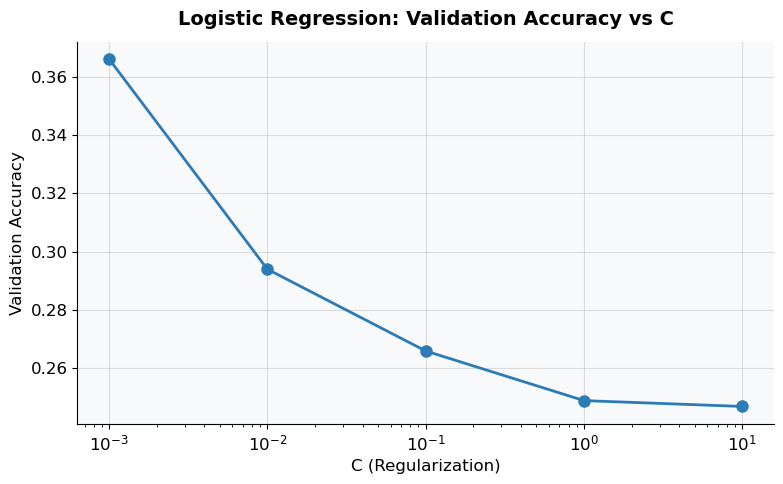


Best C (by validation): 0.001


In [39]:
# Logistic Regression - Hyperparameter search (validation)
C_values = [0.001, 0.01, 0.1, 1, 10]
lr_val_scores = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=SEED)
    lr.fit(X_train_model, y_train_model)
    score = accuracy_score(y_val, lr.predict(X_val_scaled))
    lr_val_scores.append(score)
    print(f"C={C:.3f} | Val Accuracy: {score:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_values, lr_val_scores, marker='o', color=MAIN_COLOR, linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('C (Regularization)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Logistic Regression: Validation Accuracy vs C', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

best_C_lr = C_values[int(np.argmax(lr_val_scores))]
print(f"\nBest C (by validation): {best_C_lr}")


Logistic Regression (C=0.001) - Validation Accuracy: 0.366


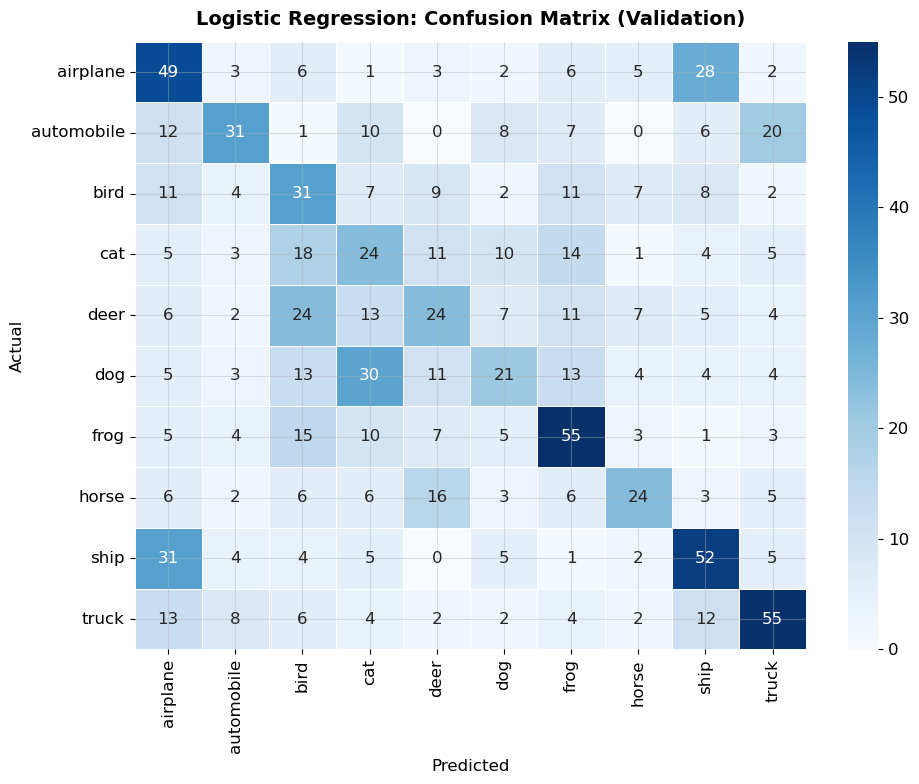

In [40]:
# Final Logistic Regression model (using best C)
best_lr = LogisticRegression(C=best_C_lr, max_iter=1000, random_state=SEED)
best_lr.fit(X_train_model, y_train_model)
y_val_pred_lr = best_lr.predict(X_val_scaled)
lr_accuracy = accuracy_score(y_val, y_val_pred_lr)
print(f"Logistic Regression (C={best_C_lr}) - Validation Accuracy: {lr_accuracy:.3f}")

# Confusion Matrix (validation)
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_val, y_val_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Logistic Regression: Confusion Matrix (Validation)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 2.3 Support Vector Machine (SVM)
We train a Linear SVM and evaluate regularization strength C. Due to high dimensionality (3,072 features), training was performed on a subset of 1,000 samples.

C=0.001 | Val Accuracy: 0.282
C=0.010 | Val Accuracy: 0.235
C=0.100 | Val Accuracy: 0.216
C=1.000 | Val Accuracy: 0.207
C=10.000 | Val Accuracy: 0.210


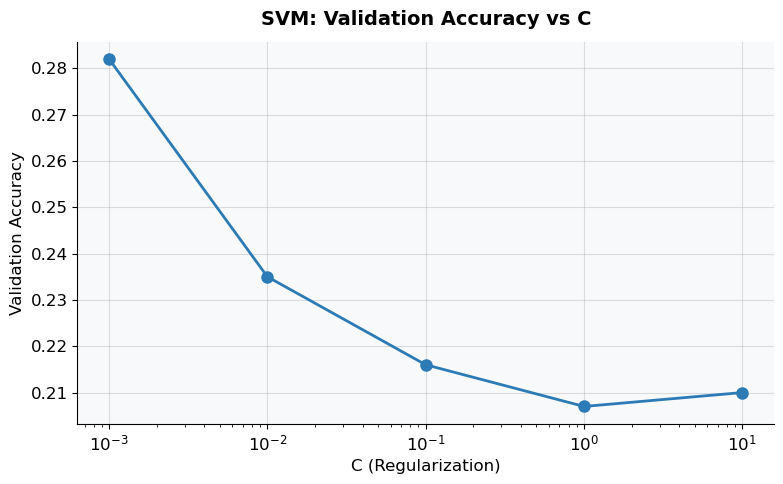


Best C (by validation): 0.001


In [41]:
# SVM (LinearSVC) - Hyperparameter search (validation)
C_values_svm = [0.001, 0.01, 0.1, 1, 10]
svm_val_scores = []

for C in C_values_svm:
    svm = LinearSVC(C=C, max_iter=2000, random_state=SEED)
    svm.fit(X_train_model, y_train_model)
    score = accuracy_score(y_val, svm.predict(X_val_scaled))
    svm_val_scores.append(score)
    print(f"C={C:.3f} | Val Accuracy: {score:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_values_svm, svm_val_scores, marker='o', color=MAIN_COLOR, linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('C (Regularization)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('SVM: Validation Accuracy vs C', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

best_C_svm = C_values_svm[int(np.argmax(svm_val_scores))]
print(f"\nBest C (by validation): {best_C_svm}")


SVM (C=0.001) - Validation Accuracy: 0.282


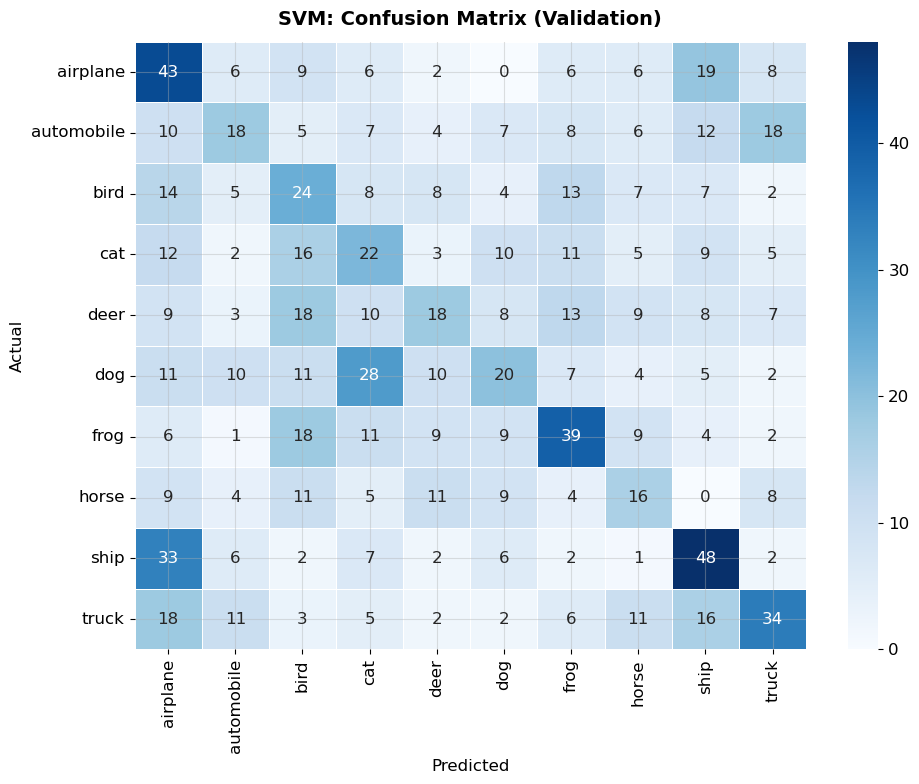

In [42]:
# Final SVM model (using best C)
best_svm = LinearSVC(C=best_C_svm, max_iter=2000, random_state=SEED)
best_svm.fit(X_train_model, y_train_model)
y_val_pred_svm = best_svm.predict(X_val_scaled)
svm_accuracy = accuracy_score(y_val, y_val_pred_svm)
print(f"SVM (C={best_C_svm}) - Validation Accuracy: {svm_accuracy:.3f}")

# Confusion Matrix (validation)
fig, ax = plt.subplots(figsize=(10, 8))
cm_svm = confusion_matrix(y_val, y_val_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('SVM: Confusion Matrix (Validation)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 2.4 KNN Classification
We evaluate K values [1, 3, 5, 7, 10] and select the best K based on validation accuracy.

k=1 | Val Accuracy: 0.248
k=3 | Val Accuracy: 0.229
k=5 | Val Accuracy: 0.240
k=7 | Val Accuracy: 0.236
k=10 | Val Accuracy: 0.210


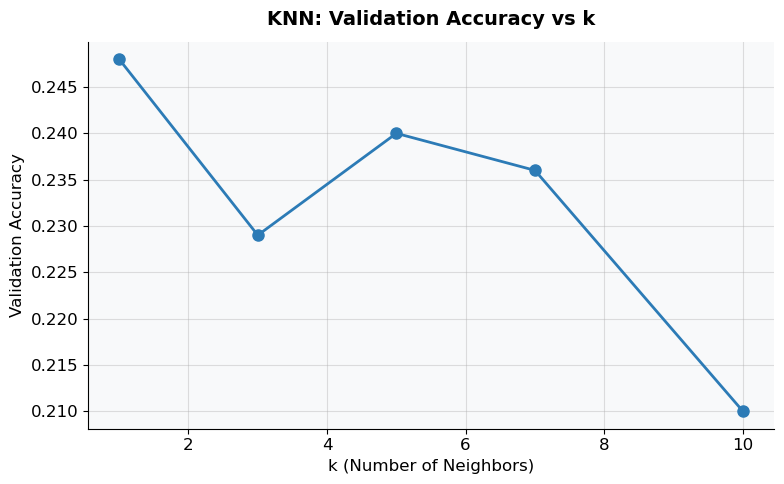


Best k (by validation): 1


In [43]:
# KNN - Hyperparameter search (validation)
k_values = [1, 3, 5, 7, 10]
knn_val_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=1)
    knn.fit(X_train_model, y_train_model)
    score = accuracy_score(y_val, knn.predict(X_val_scaled))
    knn_val_scores.append(score)
    print(f"k={k} | Val Accuracy: {score:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, knn_val_scores, marker='o', color=MAIN_COLOR, linewidth=2, markersize=8)
ax.set_xlabel('k (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('KNN: Validation Accuracy vs k', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

best_K = k_values[int(np.argmax(knn_val_scores))]
print(f"\nBest k (by validation): {best_K}")


KNN (k=1) - Validation Accuracy: 0.248


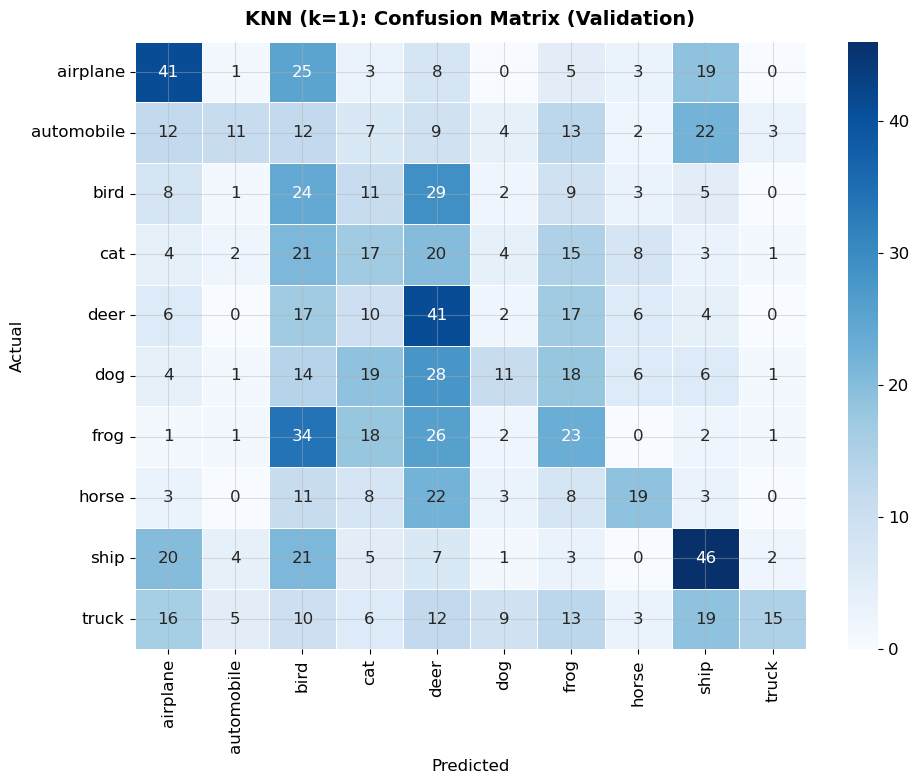

In [44]:
# Final KNN model (using best k)
best_knn_clf = KNeighborsClassifier(n_neighbors=best_K, n_jobs=1)
best_knn_clf.fit(X_train_model, y_train_model)
y_val_pred_knn = best_knn_clf.predict(X_val_scaled)
knn_accuracy = accuracy_score(y_val, y_val_pred_knn)
print(f"KNN (k={best_K}) - Validation Accuracy: {knn_accuracy:.3f}")

# Confusion Matrix (validation)
fig, ax = plt.subplots(figsize=(10, 8))
cm_knn = confusion_matrix(y_val, y_val_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'KNN (k={best_K}): Confusion Matrix (Validation)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 2.5 Model Comparison and Final Evaluation
We compare all three models on the validation set and evaluate the best model (Logistic Regression) on the held-out test set exactly once.

Model Comparison on Validation Set:
Model                            Accuracy
------------------------------------------
Logistic Regression (C=0.001)       0.366
SVM (C=0.001)                       0.282
KNN (k=1)                           0.248

Selected by validation: Logistic Regression

--- Final Model on TEST set (reported once) ---
Final model: Logistic Regression
Test Accuracy: 0.377


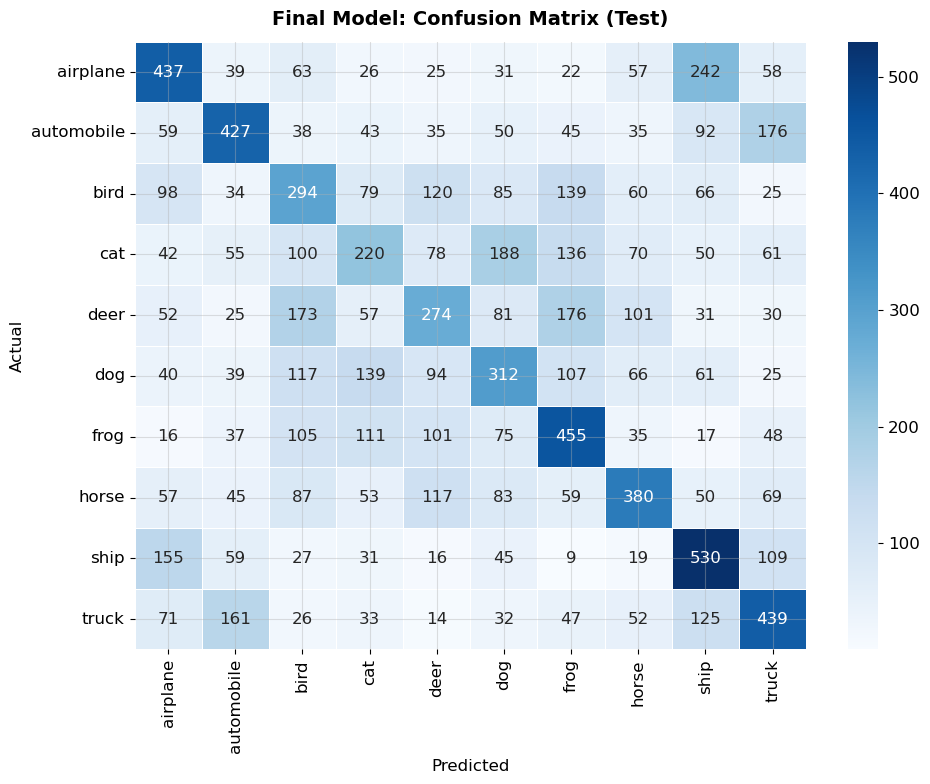

In [45]:
# Final comparison (Validation)
print("Model Comparison on Validation Set:")
print(f"{'Model':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{f'Logistic Regression (C={best_C_lr})':<30} {lr_accuracy:>10.3f}")
print(f"{f'SVM (C={best_C_svm})':<30} {svm_accuracy:>10.3f}")
print(f"{f'KNN (k={best_K})':<30} {knn_accuracy:>10.3f}")

# Select best by validation accuracy
val_scores = {
    "Logistic Regression": lr_accuracy,
    "SVM": svm_accuracy,
    "KNN": knn_accuracy
}
best_model_name = max(val_scores, key=val_scores.get)
print("\nSelected by validation:", best_model_name)

# Train final model on TRAIN+VAL and evaluate on TEST (once)
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

if best_model_name == "Logistic Regression":
    final_model = LogisticRegression(C=best_C_lr, max_iter=1000, random_state=SEED)
elif best_model_name == "SVM":
    final_model = LinearSVC(C=best_C_svm, max_iter=2000, random_state=SEED)
else:
    final_model = KNeighborsClassifier(n_neighbors=best_K, n_jobs=1)

final_model.fit(X_trainval_scaled, y_trainval)

y_test_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test_full, y_test_pred)

print("\n--- Final Model on TEST set (reported once) ---")
print("Final model:", best_model_name)
print(f"Test Accuracy: {test_accuracy:.3f}")

# Confusion Matrix (test) for the final selected model
fig, ax = plt.subplots(figsize=(10, 8))
cm_test = confusion_matrix(y_test_full, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Final Model: Confusion Matrix (Test)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


In [46]:
# Note:
# To follow the project guideline of using the TEST set only once,
# we do not run a separate "fair test comparison" for all models.
# The final TEST evaluation above is done only for the model selected by validation.


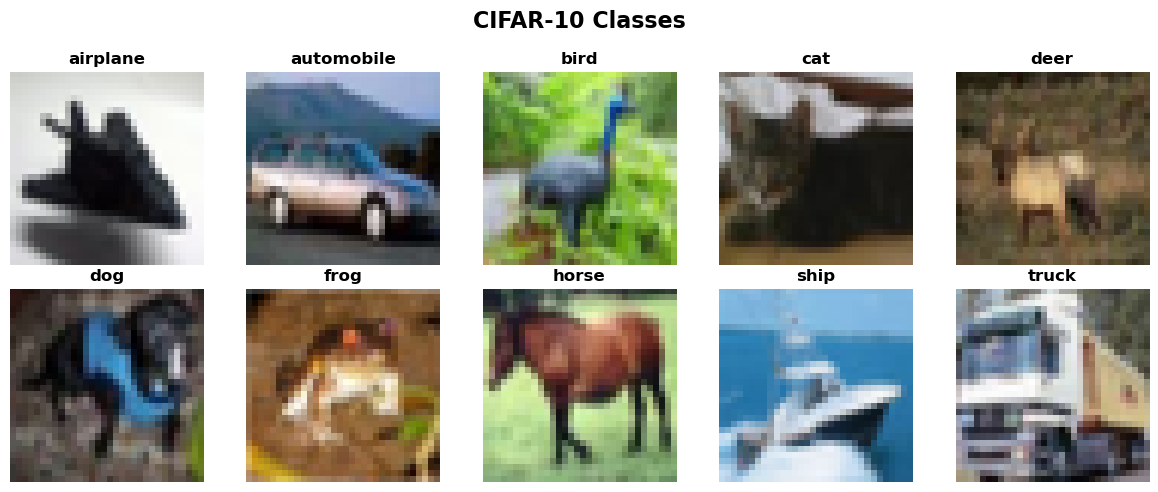

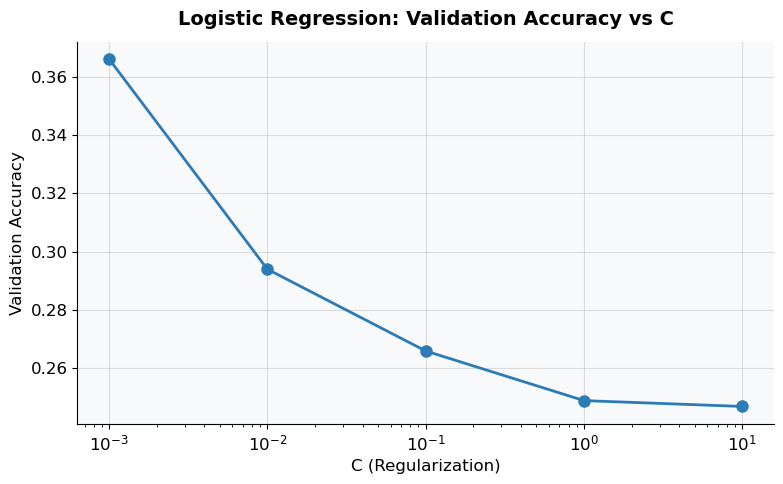

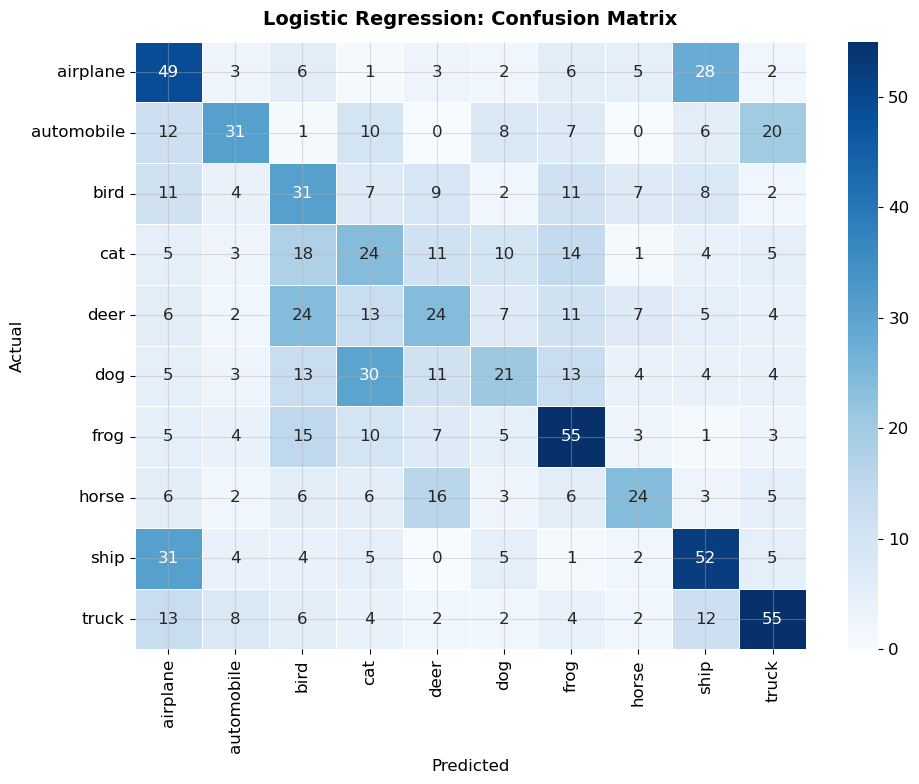

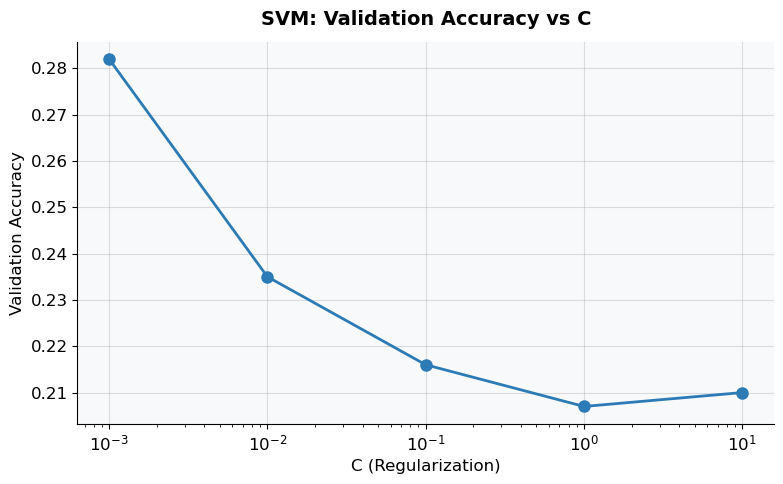

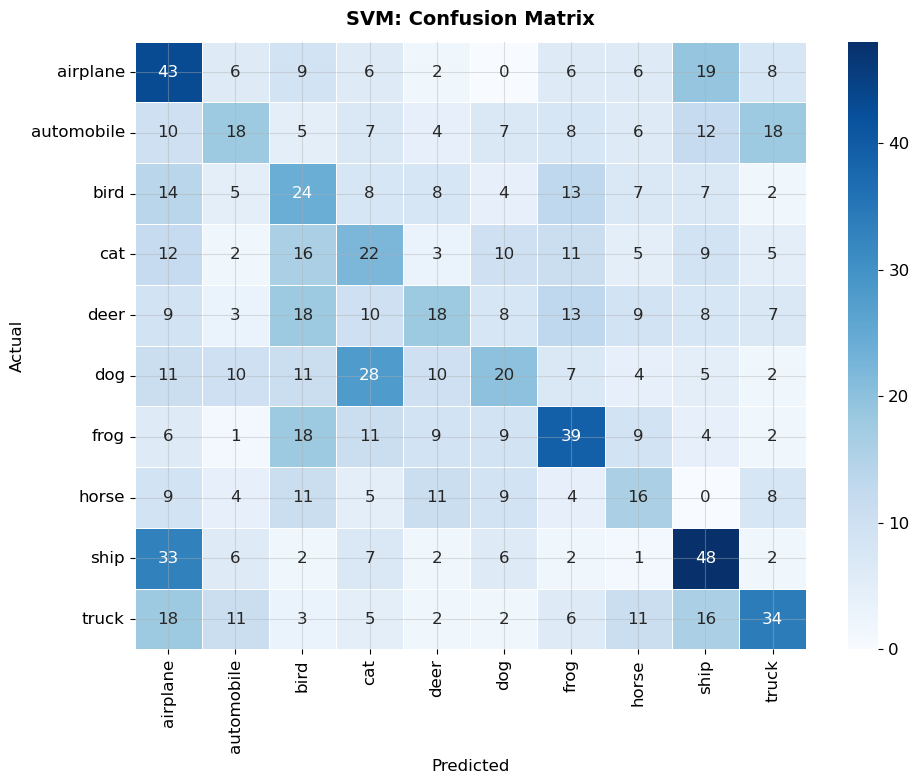

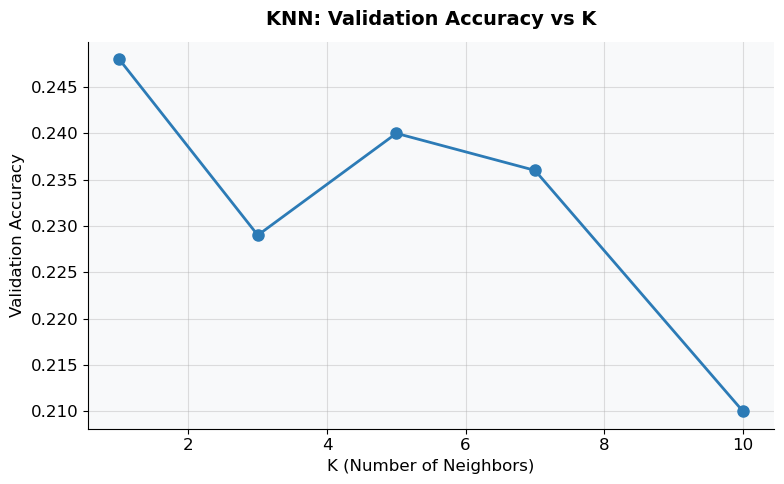

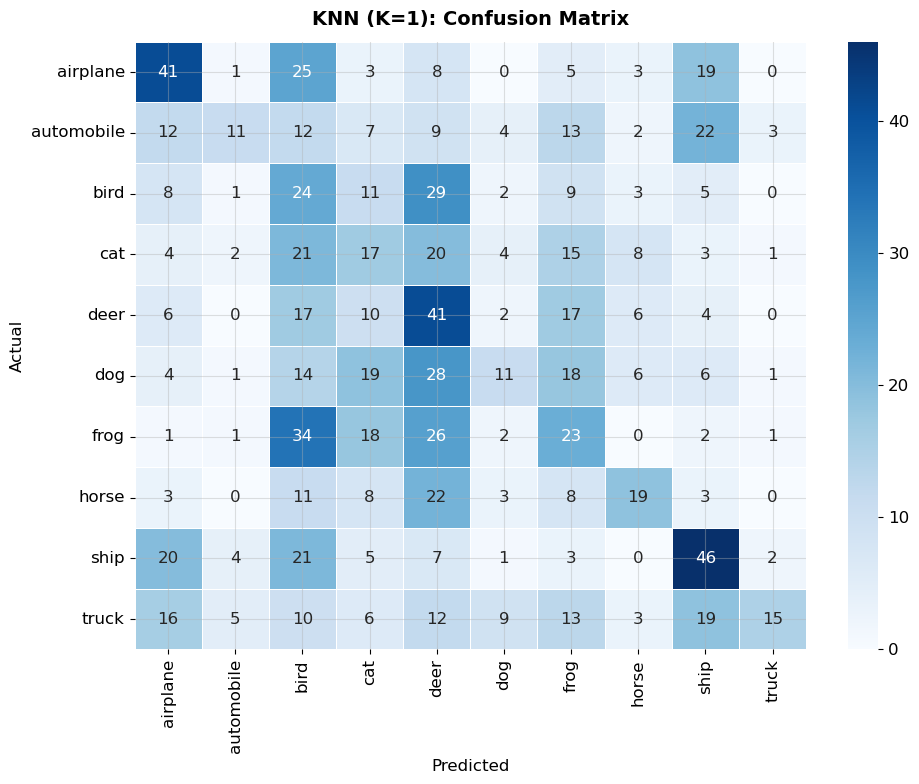

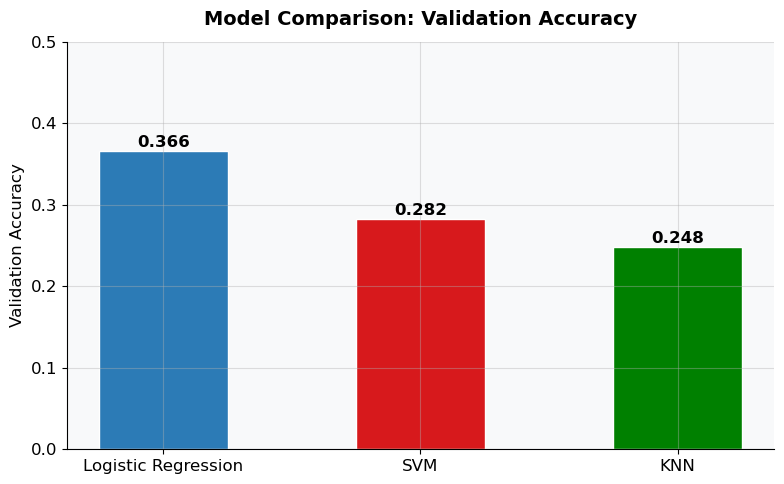

All figures saved and zipped!


In [47]:
import os
os.makedirs('figures_part2', exist_ok=True)

# Figure 1 - Sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(10):
    idx = np.where(y_train_full == i)[0][0]
    img = X_train_full[idx].reshape(3, 32, 32).transpose(1, 2, 0)
    axes[i].imshow(img)
    axes[i].set_title(class_names[i], fontsize=12, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('CIFAR-10 Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figures_part2/fig1_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2 - Logistic Regression C search
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_values, lr_val_scores, marker='o', color=MAIN_COLOR, linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('C (Regularization)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Logistic Regression: Validation Accuracy vs C', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_part2/fig2_lr_C.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 3 - LR Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_val_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Logistic Regression: Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_part2/fig3_lr_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4 - SVM C search
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(C_values_svm, svm_val_scores, marker='o', color=MAIN_COLOR, linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('C (Regularization)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('SVM: Validation Accuracy vs C', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_part2/fig4_svm_C.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 5 - SVM Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_val_pred_svm), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('SVM: Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_part2/fig5_svm_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 6 - KNN K search
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, knn_val_scores, marker='o', color=MAIN_COLOR, linewidth=2, markersize=8)
ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('KNN: Validation Accuracy vs K', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_part2/fig6_knn_K.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 7 - KNN Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_val, y_val_pred_knn), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('KNN (K=1): Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('figures_part2/fig7_knn_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 8 - Model Comparison
fig, ax = plt.subplots(figsize=(8, 5))
models = ['Logistic Regression', 'SVM', 'KNN']
accuracies = [lr_accuracy, svm_accuracy, knn_accuracy]
colors = [MAIN_COLOR, SECOND_COLOR, 'green']
bars = ax.bar(models, accuracies, color=colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Model Comparison: Validation Accuracy', fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.savefig('figures_part2/fig8_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

import shutil
shutil.make_archive('figures_part2', 'zip', 'figures_part2')
print("All figures saved and zipped!")